<a href="https://colab.research.google.com/github/houmirikhadijaencg-eng/cours-DS/blob/main/Copie_de_Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#For ignoring warning
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/input/analyse/DATA&.csv')
df

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3
...,...,...,...,...,...,...
195,S196,10.5,5.4,94.0,87,42.7
196,S197,7.1,6.1,85.1,92,40.4
197,S198,1.6,6.9,63.8,76,28.2
198,S199,12.0,7.3,50.5,58,42.0


In [ ]:
df.shape

(200, 6)

In [ ]:
#Checking for Duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
#Removing Duplicates
df=df.drop_duplicates()

In [ ]:
#Checking for null values
df.isnull().sum()

,0
student_id,0
hours_studied,0
sleep_hours,0
attendance_percent,0
previous_scores,0
exam_score,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB


In [ ]:
df.describe()

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,6.325500,6.622000,74.830000,66.800000,33.955000
std,3.227317,1.497138,14.249905,15.663869,6.789548
min,1.000000,4.000000,50.300000,40.000000,17.100000
25%,3.500000,5.300000,62.200000,54.000000,29.500000
50%,6.150000,6.700000,75.250000,67.500000,34.050000
75%,9.000000,8.025000,87.425000,80.000000,38.750000
max,12.000000,9.000000,100.000000,95.000000,51.300000


In [ ]:
from sklearn import preprocessing
le=preprocessing.LabelEncoder()
df['student_id']=le.fit_transform(df['student_id'])

In [ ]:
df

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3
...,...,...,...,...,...,...
195,S196,10.5,5.4,94.0,87,42.7
196,S197,7.1,6.1,85.1,92,40.4
197,S198,1.6,6.9,63.8,76,28.2
198,S199,12.0,7.3,50.5,58,42.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   student_id          200 non-null    int64
 1   hours_studied       200 non-null    int64
 2   sleep_hours         200 non-null    int64
 3   attendance_percent  200 non-null    int64
 4   previous_scores     200 non-null    int64
 5   exam_score          200 non-null    int64
dtypes: int64(6)
memory usage: 9.5 KB


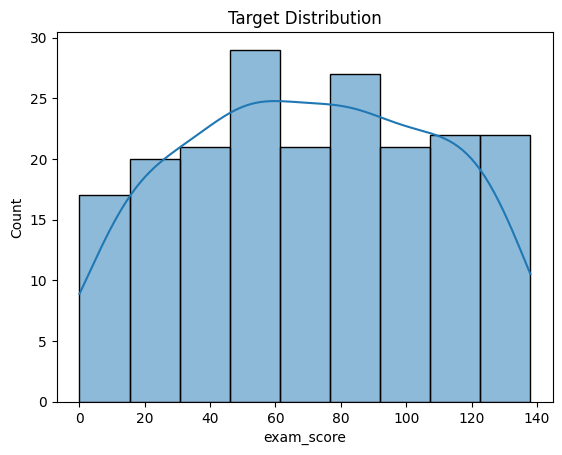

In [ ]:
#Let's check the distributaion of Target variable.
sns.histplot(x='exam_score', data=df, kde=True)
plt.title('Target Distribution');

In [ ]:
df['exam_score'].value_counts()

,count
exam_score,
87,5
52,3
84,3
50,3
34,3
...,...
134,1
69,1
112,1


In [ ]:
# function for plotting
def plot(col, df=df):
    return df.groupby(col)['exam_score'].value_counts(normalize=True).unstack().plot(kind='bar', figsize=(8,5))

<Axes: xlabel='student_id'>

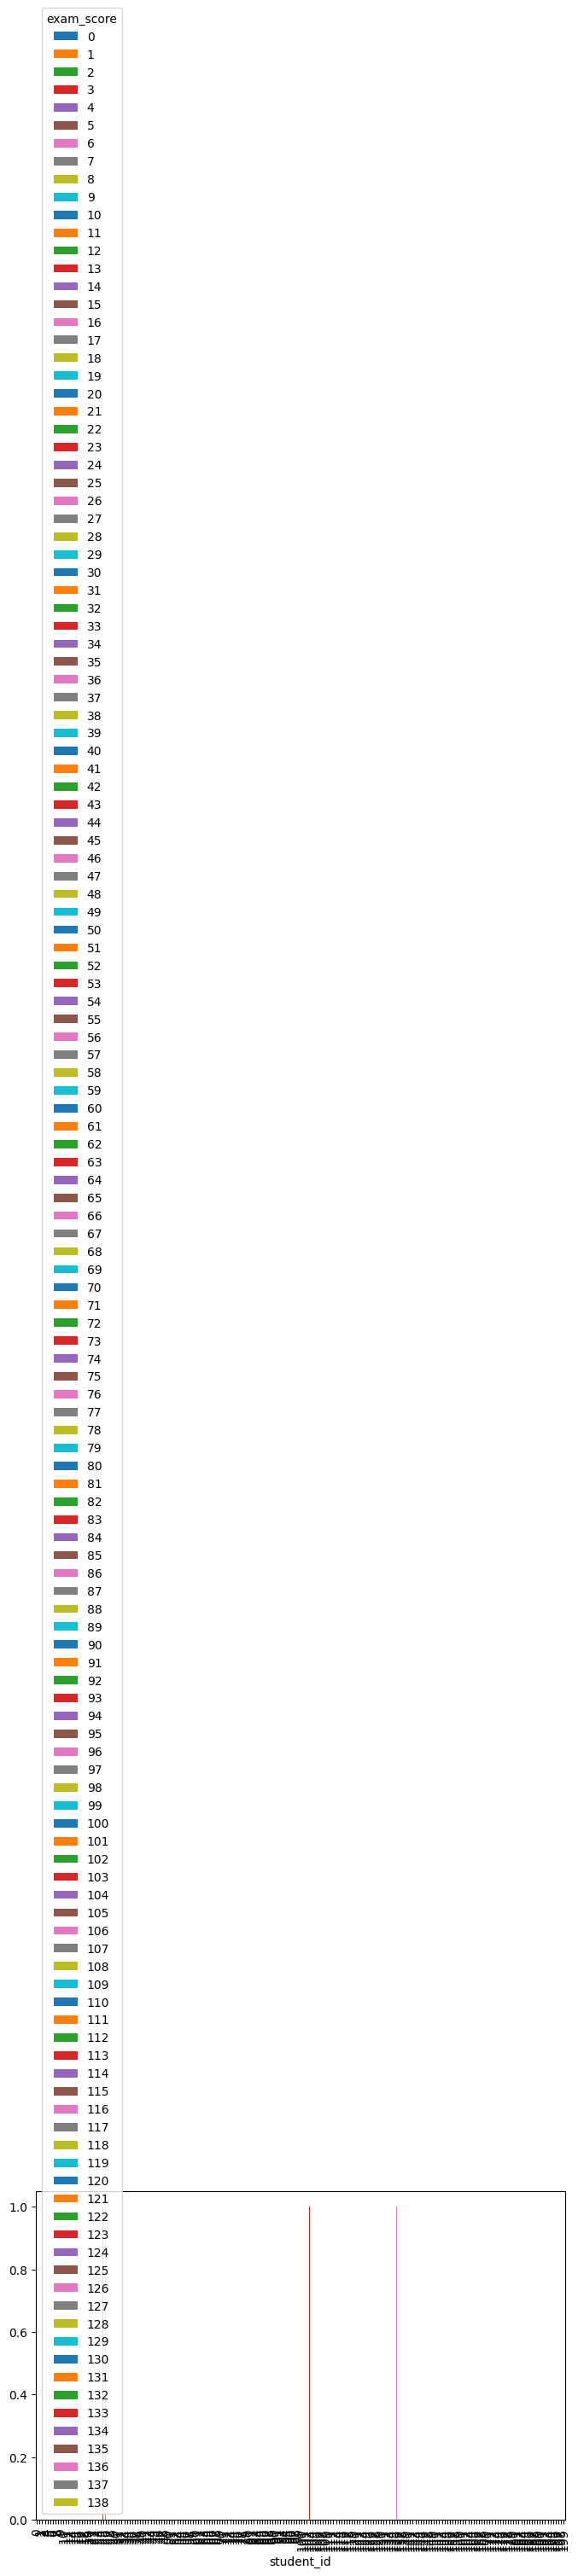

In [ ]:
plot('student_id')

<Axes: xlabel='hours_studied'>

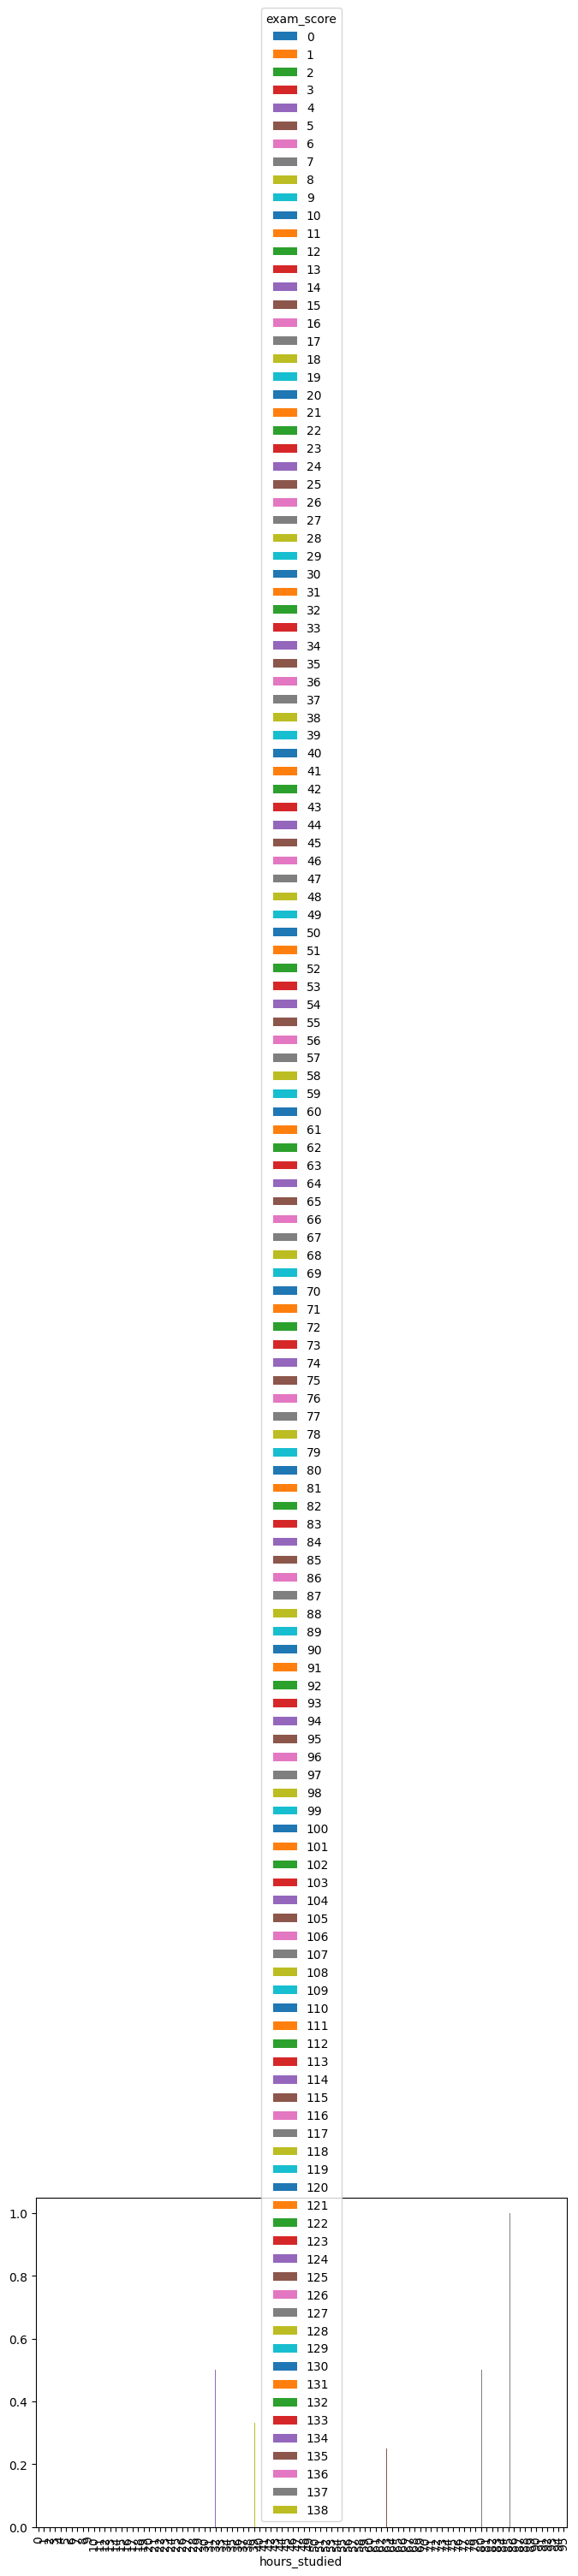

In [ ]:
plot('hours_studied')

In [ ]:
#Finding Correlation
cn=df_new.corr()
cn

,student_id,exam_score
student_id,1.000000,0.022219
exam_score,0.022219,1.000000


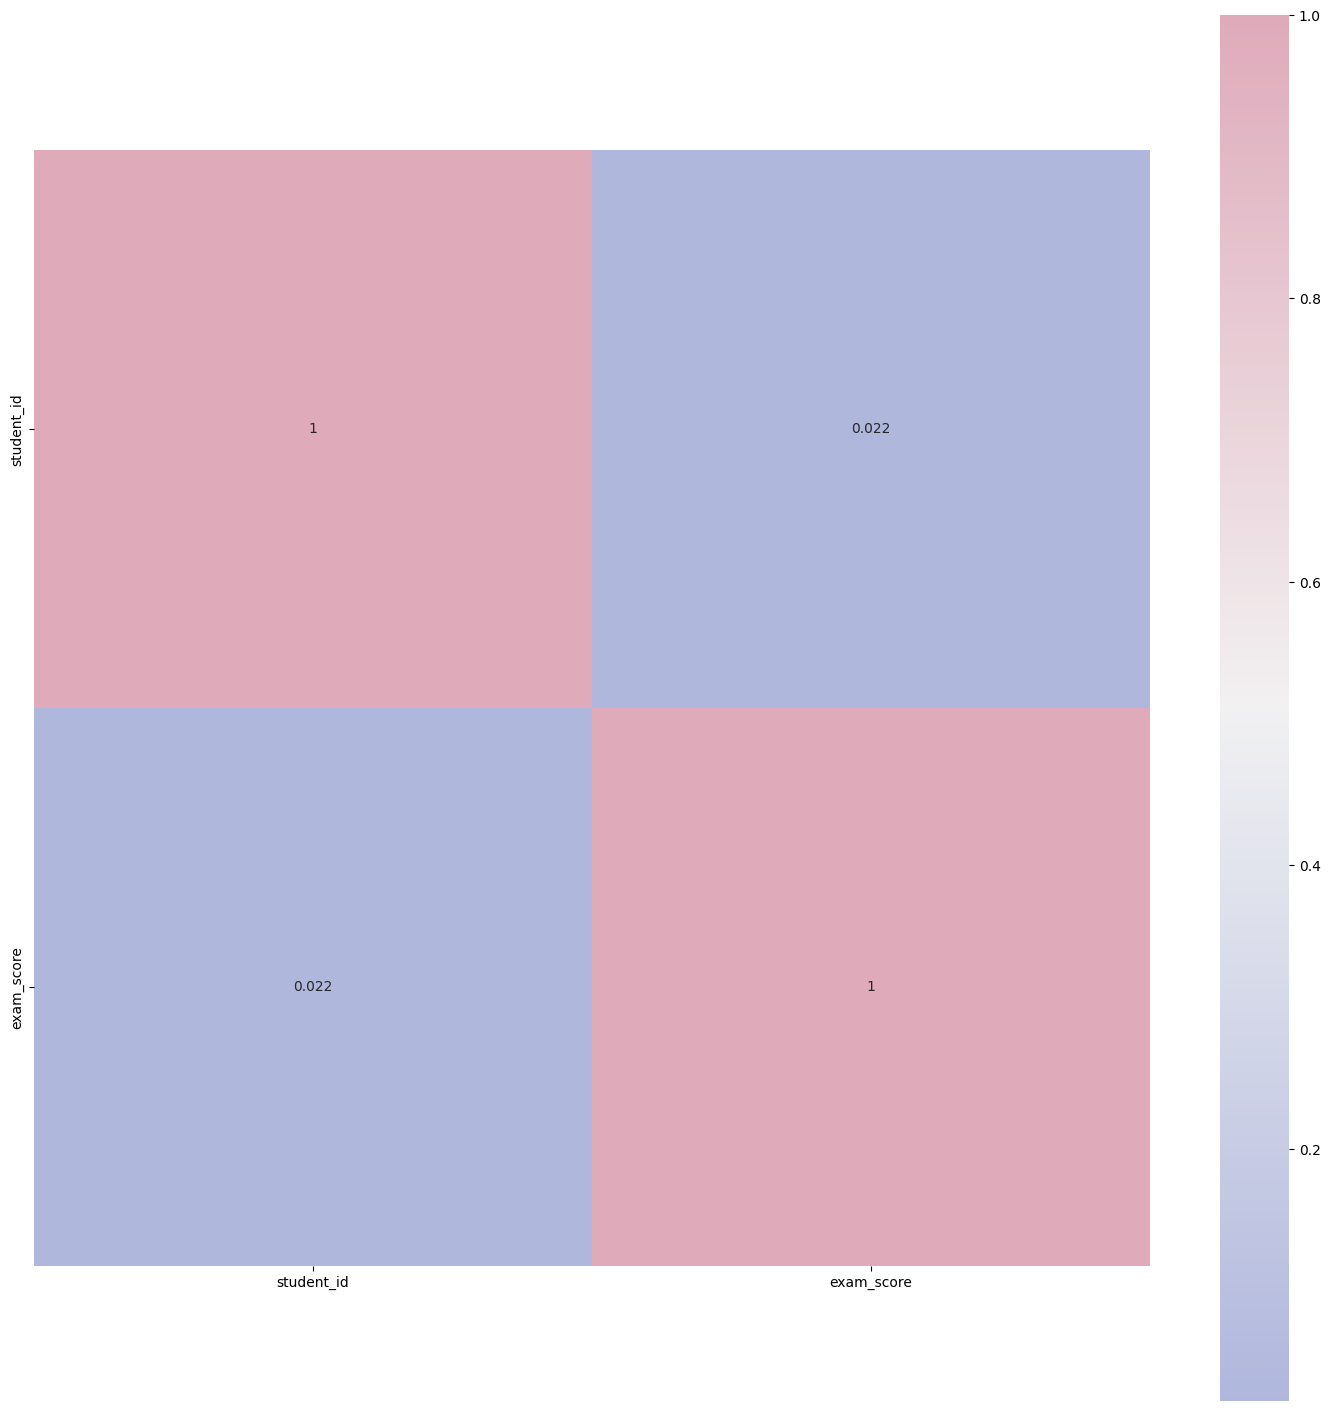

In [ ]:
#Correlation
cmap=sns.diverging_palette(260,-10,s=50, l=75, n=6,
as_cmap=True)
plt.subplots(figsize=(18,18))
sns.heatmap(cn,cmap=cmap,annot=True, square=True)
plt.show()

<Axes: >

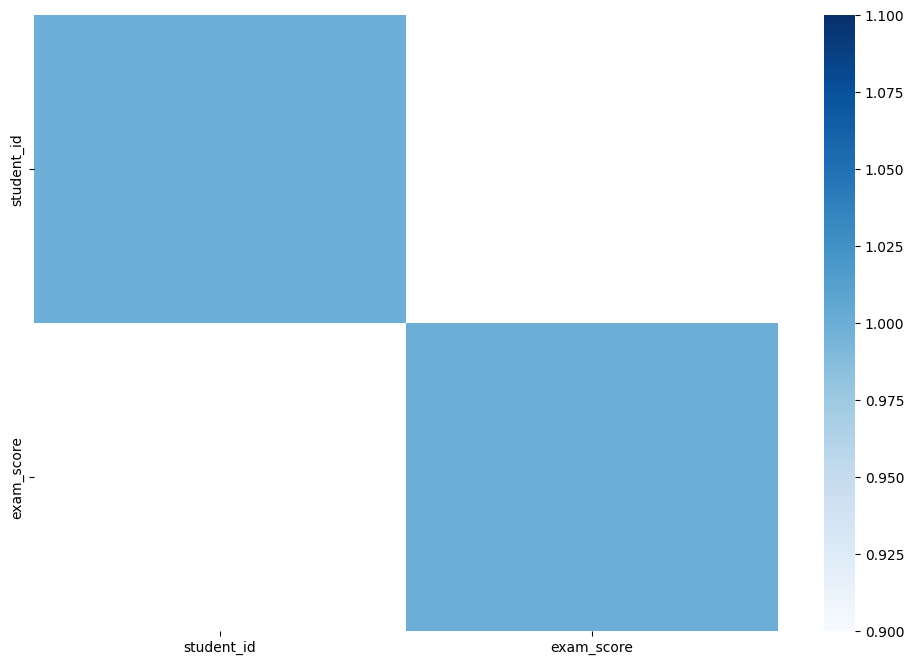

In [ ]:
kot = cn[cn>=.40]
plt.figure(figsize=(12,8))
sns.heatmap(kot, cmap="Blues")

In [ ]:
df_new['student_id']=df_new['student_id']*df_new['exam_score']
df_new

,student_id,exam_score
0,0,47
1,18,18
2,168,84
3,210,70
4,444,111
...,...,...
195,23985,123
196,21952,112
197,6107,31
198,23760,120


In [ ]:
#Splitting independent and dependent variables
X = df_new.drop('exam_score', axis = 1)
y = df_new['exam_score']

In [ ]:
from imblearn.over_sampling import ADASYN
adasyn = ADASYN(random_state=42)
X, y = adasyn.fit_resample(X, y)


ValueError: Expected n_neighbors <= n_samples_fit, but n_neighbors = 6, n_samples_fit = 1, n_samples = 1